In [1]:
# Install required libraries

!pip install -q nltk wordcloud seaborn

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Download NLTK stopwords

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
# Download the SMS Spam Collection dataset from Kaggle

!wget -q https://www.kaggle.com/api/v1/datasets/download/uciml/sms-spam-collection-dataset -O spam_dataset.zip

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [5]:
# Extract the downloaded ZIP file

!unzip -o spam_dataset.zip

print("Dataset extracted successfully!")

Archive:  spam_dataset.zip
  inflating: spam.csv                
Dataset extracted successfully!


In [6]:
# Load the dataset

df = pd.read_csv('spam.csv', encoding='latin-1')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
# Keep only the columns required for our project

df = df[['v1', 'v2']]

# Rename columns for better readability

df.columns = ['label', 'message']

print("Updated dataset shape:", df.shape)

df.head()

Updated dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# Check basic information about the dataset

print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
# Check for missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
label      0
message    0
dtype: int64


In [10]:
# Remove missing values

df = df.dropna()

# Remove duplicate messages

df = df.drop_duplicates()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (5169, 2)


In [11]:
# Count the number of spam and ham messages

class_counts = df['label'].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


In [12]:
# Calculate percentage of each class

class_percentages = df['label'].value_counts(normalize=True) * 100

print("Class Percentage:")
print(class_percentages.round(2))

Class Percentage:
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


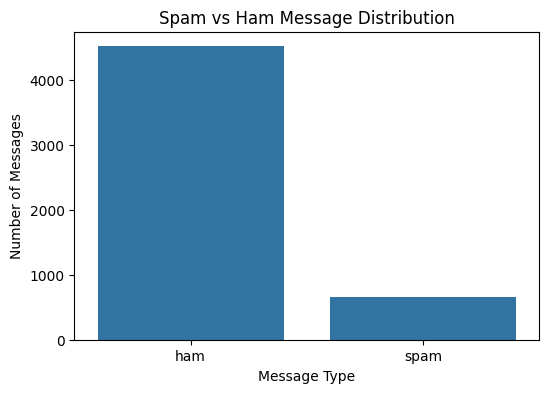

In [13]:
# Visualize the class distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='label')

plt.title('Spam vs Ham Message Distribution')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [16]:
# Convert text labels into numerical labels

df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [17]:
# Text preprocessing function

def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Split text into individual words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join the words back into a sentence
    text = ' '.join(words)

    return text

In [18]:
# Text preprocessing function

def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Split text into individual words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join the words back into a sentence
    text = ' '.join(words)

    return text

In [20]:
# Apply preprocessing to the 'message' column
df['clean_message'] = df['message'].apply(preprocess_text)

# Separate features and target

X = df['clean_message']
y = df['label_num']

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [22]:
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit TF-IDF only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vectorizer
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

TF-IDF transformation completed!
Training matrix shape: (4135, 5000)
Testing matrix shape: (1034, 5000)


In [23]:
# Create Multinomial Naive Bayes model

nb_model = MultinomialNB()

# Train the model

nb_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [24]:
# Predict the test dataset

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [25]:
# Evaluate Naive Bayes

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes Results")
print("--------------------------------")

print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-score :", round(f1_nb, 4))

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.9652
Precision: 0.9897
Recall   : 0.7328
F1-score : 0.8421


In [26]:
# Detailed classification report

print("Classification Report - Naive Bayes")
print()

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=['Ham', 'Spam']
    )
)

Classification Report - Naive Bayes

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



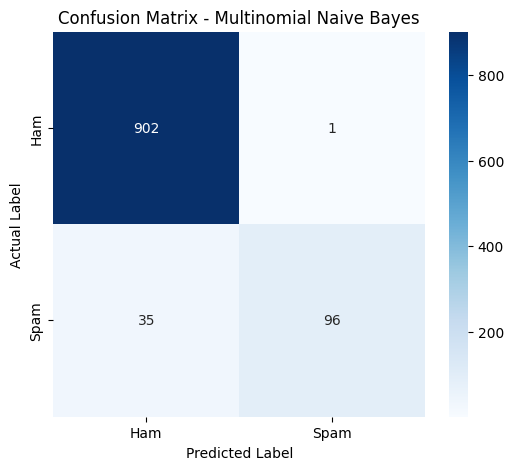

In [27]:
# Create confusion matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [28]:
# Create Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [29]:
# Make predictions using Logistic Regression

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression predictions generated successfully!")

Logistic Regression predictions generated successfully!


In [30]:
# Evaluate Logistic Regression

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")

print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-score :", round(f1_lr, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.9555
Precision: 0.9775
Recall   : 0.6641
F1-score : 0.7909


In [31]:
# Detailed classification report

print("Classification Report - Logistic Regression")
print()

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Ham', 'Spam']
    )
)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       903
        Spam       0.98      0.66      0.79       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.88      1034
weighted avg       0.96      0.96      0.95      1034



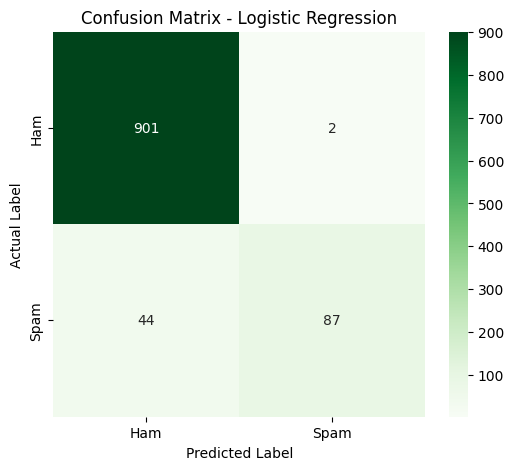

In [32]:
# Create confusion matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [33]:
# Compare both machine learning models

results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression'
    ],
    'Accuracy': [
        accuracy_nb,
        accuracy_lr
    ],
    'Precision': [
        precision_nb,
        precision_lr
    ],
    'Recall': [
        recall_nb,
        recall_lr
    ],
    'F1-Score': [
        f1_nb,
        f1_lr
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9652,0.9897,0.7328,0.8421
1,Logistic Regression,0.9555,0.9775,0.6641,0.7909


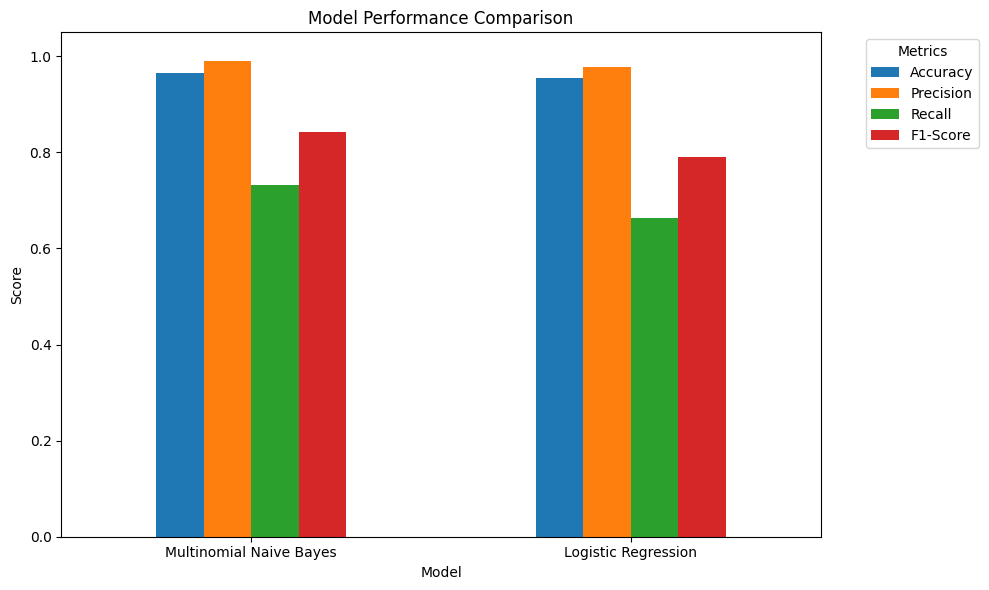

In [34]:
# Plot model performance comparison

results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.legend(
    title='Metrics',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [35]:
!pip install -q wordcloud

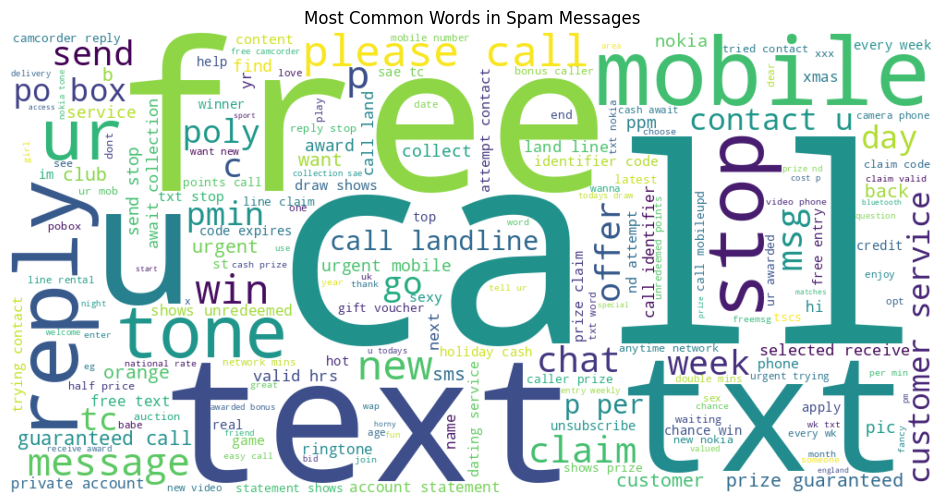

In [36]:
from wordcloud import WordCloud

# Combine all spam messages

spam_text = ' '.join(
    df[df['label'] == 'spam']['clean_message']
)

# Generate WordCloud

spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(spam_text)

# Display WordCloud

plt.figure(figsize=(12, 6))

plt.imshow(spam_wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Most Common Words in Spam Messages')

plt.show()

In [38]:
# Function to predict whether a new message is spam or ham

def predict_message(message):

    # Preprocess the message
    cleaned_message = preprocess_text(message)

    # Convert text into TF-IDF features
    message_tfidf = tfidf.transform([cleaned_message])

    # Predict using Naive Bayes
    prediction = nb_model.predict(message_tfidf)[0]

    # Convert numerical prediction back to label
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [39]:
# Test example messages

test_messages = [
    "Congratulations! You won a free prize. Click now to claim.",
    "Hey, are you coming to college tomorrow?",
    "URGENT! You have won 10000 rupees. Call now!",
    "Can you send me the project report?"
]

for message in test_messages:

    result = predict_message(message)

    print("Message:", message)
    print("Prediction:", result)
    print("-" * 70)

Message: Congratulations! You won a free prize. Click now to claim.
Prediction: SPAM
----------------------------------------------------------------------
Message: Hey, are you coming to college tomorrow?
Prediction: HAM
----------------------------------------------------------------------
Message: URGENT! You have won 10000 rupees. Call now!
Prediction: SPAM
----------------------------------------------------------------------
Message: Can you send me the project report?
Prediction: HAM
----------------------------------------------------------------------


In [ ]:
# Conclusion

In this project, an NLP-based binary classification system was developed to distinguish spam messages from legitimate ham messages.

The SMS Spam Collection dataset was cleaned and preprocessed using lowercase conversion, punctuation removal, and stopword removal.

TF-IDF was used to convert text messages into numerical features.

Two machine learning algorithms were trained:

1. Multinomial Naive Bayes
2. Logistic Regression

Both models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Recall is particularly important in spam detection because missing an actual spam message can allow unwanted or potentially harmful messages to reach the user.

The project demonstrates how Natural Language Processing and machine learning can be combined to automatically classify text messages.